# KKBOX Churn Prediction — Final Model

`05_ml_comparison.ipynb`(ML)와 `05_dl_comparison.ipynb`(DL)의 결과를 바탕으로 **최종 모델을 선정하고, 다시 학습·평가·저장**하는 노트북입니다.

### 선정 결과: **LightGBM (Optuna 튜닝)**

| 구분 | 후보 | 비교 기준 | 결과 |
|---|---|---|---|
| ML | CatBoost / LightGBM / XGBoost | 5-fold CV ROC-AUC | LightGBM 튜닝 0.8708 ≈ CatBoost 튜닝 0.8701 > XGBoost 0.8568 |
| DL | MLP 4종 (Baseline / BN / Dropout / BN+Dropout) | ROC-AUC | BN+Dropout MLP 0.8485 (Test) |
| **ML vs DL** | LightGBM vs BN+Dropout MLP | **같은 Test 20,000건, F1 최대 기준선** | **LightGBM 우위** (아래 5장) |

### 선정 근거
1. **성능**: Test ROC-AUC 0.8719 vs 0.8485 (차이 0.023). CV fold 표준편차(±0.004~0.006)보다 훨씬 큰 차이. 이탈(8.95%) 같은 소수 클래스를 얼마나 잘 잡는지 보여주는 **PR-AUC**도 0.6116 vs 0.5855로 우위.
2. **CatBoost와는 사실상 동점** (CV 차이 0.0007, 표준편차 이내) → 학습 속도가 빠르고 SHAP 해석이 쉬운 **LightGBM** 선택.
3. **해석 가능성**: 피처 중요도·SHAP으로 이탈 요인을 설명할 수 있어 이탈 관리 액션으로 연결하기 쉬움.

> 참고: DL 비교표의 Dropout MLP는 Validation 점수이고, 모델마다 기준선(0.5 / 0.755)이 달라 재현율·F1은 모델끼리 직접 비교하지 않고 ROC-AUC·PR-AUC로 비교함.

# 1. Data Load

In [2]:
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지: 운영체제별 기본 한글 폰트 지정
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호가 네모로 깨지는 것 방지

TODAY = pd.to_datetime('2017-02-28')
df_all = pd.read_csv("../../data/processed/integrated_data.csv")

In [3]:
import easydict

args = easydict.EasyDict()
args.seed = 42
args.target = df_all['is_churn']

In [4]:
# 클래스 비율
df_all['is_churn'].value_counts()
df_all['is_churn'].value_counts() / df_all.shape[0]

# 전체 평균 이탈률: 모든 그래프의 비교 기준선
OVERALL = df_all["is_churn"].mean()  
print(f"전체 이탈률: {OVERALL:.2%}")

전체 이탈률: 8.95%


# 2. Feature Engineering
`05_ml_comparison.ipynb`와 동일한 로직입니다. (그래프 전용 컬럼·탐색용 셀은 제외)

In [5]:
member_cols = ['city', 'bd', 'registered_via', 'registration_init_time']
df_all['has_member'] = (~df_all[member_cols].isna().all(axis=1)).astype(int)
#msno는있지만 다른 정보가 없는사람과 있는사람을 구분하는 컬럼
df_all['has_member'].value_counts()

has_member
1    88648
0    11352
Name: count, dtype: int64

In [6]:
df_all['registration_init_time']= df_all['registration_init_time'].astype('Int64')

In [7]:
df_all['registration_init_time'] = pd.to_datetime(
    df_all['registration_init_time'].astype(str),
    format='%Y%m%d',     # 연4·월2·일2
    errors='coerce',     # 변환 불가 값은 에러 대신 NaN
)

reg = df_all['registration_init_time']
df_all['tenure_date'] = (TODAY- reg).dt.days  #가입 후 경과 일수

In [8]:
df_all['reg_year'] = reg.dt.year                            # 가입 연도

season_map = {3: '봄', 4: '봄', 5: '봄', 6: '여름', 7: '여름', 8: '여름',
              9: '가을', 10: '가을', 11: '가을', 12: '겨울', 1: '겨울', 2: '겨울'}
df_all['reg_season'] = reg.dt.month.map(season_map)         # 결측은 NaN → 10단계에서 채움

# 같은 날 가입 인원. groupby는 결측 키를 기본으로 빼서, members 없는 사람은 NaN
df_all['same_join_day'] = df_all.groupby('registration_init_time')['msno'].transform('count')

In [9]:
# 성별: 결측을 '미입력'이라는 하나의 그룹으로 취급
df_all["gender_status"] = df_all["gender"].fillna("미입력")
df_all["gender_status"].unique()

array(['female', '미입력', 'male'], dtype=object)

In [10]:
# ── 4. 나이 정제 ──
bd = df_all['bd'].astype(float)
df_all['bd_clean'] = bd.where(bd.between(10, 80))           # 10~80세만 남기고 나머지 NaN
df_all['bd_isnan'] = df_all['bd_clean'].isna().astype(int)  # 나이 모름 = 1

# ── 5. 가입 당시 나이 ──
df_all['age_at_reg'] = df_all['bd_clean'] - df_all['tenure_date'] / 365

In [11]:
# ── 6. 도시 ──
df_all['city_miss'] = (df_all['city'] == 1).astype(int)    # city 1(기본값 추정) = 1. NaN은 False → 0

city_int = df_all['city'].fillna(-1).astype(int)            # 결측 → -1 (members 없음)
city_counts = city_int.value_counts()
rare_cities = city_counts[city_counts < 500].index.difference([-1])   # 500명 미만 도시 (-1은 제외)
df_all['city_clean'] = city_int.where(~city_int.isin(rare_cities), 777)  # 희소 도시 → 777(기타)

# ── 7. 가입 경로 결측 ──
df_all['registered_via'] = df_all['registered_via'].fillna(-1).astype(int)   # 결측 → -1

# ── 9. 계절 결측 ──
df_all['reg_season'] = df_all['reg_season'].fillna('unknown')

# ── 10. 범주형 지정 ──
cat_cols = ['registered_via', 'city_clean', 'gender_status', 'reg_season']
df_all[cat_cols] = df_all[cat_cols].astype('category')

In [12]:
# ── 1. 가입 기간으로 나누기 ──
# 30일 미만은 30일로 올려서 나누기 폭주 방지. 가입정보 없으면 NaN

TRANS_START = pd.to_datetime('2015-01-01')
active_days = (TODAY - df_all['registration_init_time'].clip(lower=TRANS_START)).dt.days
active_years = active_days.clip(lower=30) / 365



df_all['trans_per_year']  = df_all['transaction_count'] / active_years   # 1년에 결제한 횟수
df_all['pay_per_year']    = df_all['total_payment'] / active_years       # 1년에 낸 금액
df_all['cancel_per_year'] = df_all['cancel_count'] / active_years        # 1년에 해지한 횟수


# ── 3. 데이터 유무 3부류 ──
df_all['data_group'] = np.select(
    [df_all['has_member'] == 0, df_all['has_log'] == 0],
    ['정보·로그 없음', '로그만 없음'],
    default='둘 다 있음',
)
df_all['data_group'] = df_all['data_group'].astype('category')

In [13]:
def safe_divide(numerator, denominator):
    return numerator / denominator.replace(0, np.nan)


def add_features(data):
    data = data.copy()

    # 0 값 자체가 의미를 가질 수 있는 보조 flag
    data["no_unique_song"] = (data["total_num_unq"] == 0).astype(int)
    data["zero_plan_days"] = (data["last_plan_days"] == 0).astype(int)

    data["avg_payment"] = safe_divide(
        data["total_payment"],
        data["transaction_count"]
    )

    # 이용 로그 관련
    data["avg_daily_secs"] = safe_divide(
        data["total_secs"],
        data["activity_days"]
    )

    data["avg_daily_complete"] = safe_divide(
        data["total_num_100"],
        data["activity_days"]
    )

    data["avg_daily_unq"] = safe_divide(
        data["total_num_unq"],
        data["activity_days"]
    )

    data["complete_per_unq"] = safe_divide(
        data["total_num_100"],
        data["total_num_unq"]
    )

    # 결제 효율 관련
    data["payment_per_plan_day"] = safe_divide(
        data["avg_payment"],
        data["last_plan_days"]
    )

    return data


df_all = add_features(df_all)

# 3. Final Features & Train/Test Split
최종 피처 33개 (범주형 3 + 수치형 30). 선정 사유는 `05_ml_comparison.ipynb`의 피처 조합 비교 메모 참고.

In [14]:
ids = ['msno']
targets = 'is_churn'

categories = [
    'registered_via', 'city_clean', 'gender_status',
    #'reg_season',
]

numbers = [
    # members (본인)
    'has_member', 'tenure_date', 'same_join_day',
    'bd_clean', 'bd_isnan', 'age_at_reg', 'city_miss',

    # 거래 (팀 통합)
    'transaction_count', 'cancel_count', 'total_payment',
    'last_auto_renew', 'last_is_cancel', 'last_plan_days',
    'cancel_on_last_date', 'has_transaction',

    # 로그 (팀 통합)
    'activity_days', 'total_secs', 'total_num_100', 'total_num_unq',
    'days_since_last_log', 'has_log',

    #members 결합 (본인)
    'trans_per_year', #'pay_per_year',

     # 소희 (제외 여부는 아래 '피처 조합 비교' 결과로 판단 → 결과표 아래 메모에 사유 기록)
     #'inactive_7days', 'completed_per_hour', 'cancel_rate',
     #'no_auto_renew_low_activity', 'long_tenure_low_activity',

    # # 선아
    'avg_payment', 
    'avg_daily_secs', 'avg_daily_complete', 'avg_daily_unq',
    'complete_per_unq', 'payment_per_plan_day',
    'no_unique_song', 'zero_plan_days',
]

all_col = categories + numbers
print(f"범주형 {len(categories)}개 + 수치형 {len(numbers)}개 = {len(all_col)}개")   # 현재 3 + 30 = 33개

범주형 3개 + 수치형 30개 = 33개


In [15]:
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(df_all.index, random_state=args.seed,
                                       test_size=0.2, stratify=df_all[targets])

# ── 분할 후 재계산: 테스트 정보가 섞이지 않도록 학습 데이터로만 계산 ──
# (1) same_join_day: 학습 데이터에서 같은 날 가입한 인원 수
join_cnt = df_all.loc[train_idx].groupby('registration_init_time')['msno'].count()
sjd = df_all['registration_init_time'].map(join_cnt)
df_all['same_join_day'] = sjd.where(df_all['registration_init_time'].isna(), sjd.fillna(0))

# (2) city_clean: 학습 데이터 기준 400명 미만 도시 → 777(기타)
city_int = df_all['city'].fillna(-1).astype(int)
city_cnt_tr = city_int.loc[train_idx].value_counts()
keep_cities = city_cnt_tr[city_cnt_tr >= 400].index.union([-1])
df_all['city_clean'] = city_int.where(city_int.isin(keep_cities), 777)

df_all[categories] = df_all[categories].astype('category')

x_train, x_test = df_all.loc[train_idx, all_col], df_all.loc[test_idx, all_col]
y_train, y_test = df_all.loc[train_idx, targets], df_all.loc[test_idx, targets]

x_train.shape, y_train.shape, x_test.shape, y_test.shape

((80000, 33), (80000,), (20000, 33), (20000,))

# 4. Final Model — LightGBM (Tuned)
`05_ml_comparison.ipynb`의 Optuna 탐색 결과(최적 파라미터)를 고정해서 train 80,000건으로 다시 학습합니다.

In [16]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

from common.models import ModelType
from common.evaluate import get_score, evaluate
from common.cross_validation import fit_params_for

In [17]:
BEST_NAME = "lgb"
BEST_PARAMS = {
    'n_estimators': 200,
    'learning_rate': 0.02008331932698382,
    'num_leaves': 53,
    'min_child_samples': 41,
}

final_model = ModelType[BEST_NAME].create(args.seed, **BEST_PARAMS)
final_model.fit(x_train, y_train, **fit_params_for(BEST_NAME, categories))

score = evaluate(final_model, [x_train, y_train], [x_test, y_test])
display(pd.DataFrame({
    k: {"ROC-AUC": s["auc_score"], "PR-AUC": s["pr_auc"]} for k, s in score.items()
}).T.round(4))
print("※ 05_ml_comparison 기록: test ROC-AUC 0.8719 / PR-AUC 0.6116 — 같으면 재현 성공")

,ROC-AUC,PR-AUC
train_score,0.9071,0.6756
test_score,0.8719,0.6116


※ 05_ml_comparison 기록: test ROC-AUC 0.8719 / PR-AUC 0.6116 — 같으면 재현 성공


## Threshold Tuning
테스트 데이터를 보지 않도록 **학습 데이터 5-fold 교차검증 예측**으로 F1이 최대가 되는 기준선을 정합니다.

In [18]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import precision_recall_curve

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=args.seed)
proba_cv = cross_val_predict(ModelType[BEST_NAME].create(args.seed, **BEST_PARAMS),
                             x_train, y_train, cv=skf, method="predict_proba",
                             params=fit_params_for(BEST_NAME, categories))[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, proba_cv)
f1 = 2 * precision * recall / (precision + recall + 1e-9)
best = f1[:-1].argmax()
TH = float(thresholds[best])
print(f"기준선: {TH:.3f} (CV 재현율 {recall[best]:.3f}, 정밀도 {precision[best]:.3f})")

기준선: 0.282 (CV 재현율 0.531, 정밀도 0.633)


# 5. Final Evaluation & ML vs DL Comparison

In [19]:
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score,
                             recall_score, f1_score, classification_report, confusion_matrix)

proba_te = final_model.predict_proba(x_test)[:, 1]

def summarize(y, proba, th):
    pred = (proba >= th).astype(int)
    return {"ROC-AUC": roc_auc_score(y, proba), "PR-AUC": average_precision_score(y, proba),
            "기준선": th, "재현율": recall_score(y, pred), "정밀도": precision_score(y, pred),
            "F1": f1_score(y, pred)}

lgb_05 = summarize(y_test, proba_te, 0.5)
lgb_th = summarize(y_test, proba_te, TH)

# DL 최고 모델(BN+Dropout MLP) 결과: 05_dl_comparison.ipynb 셀 176·178 (같은 test 20,000건, 검증셋 F1 최대 기준선)
mlp = {"ROC-AUC": 0.8485, "PR-AUC": 0.5855, "기준선": 0.7548,
       "재현율": 0.5536, "정밀도": 0.5742, "F1": 0.5637}

final_cmp = pd.DataFrame({
    "LightGBM (기준선 0.5)": lgb_05,
    f"LightGBM (기준선 {TH:.3f}) ★최종": lgb_th,
    "MLP BN+Dropout (DL 1위)": mlp,
}).round(4)
display(final_cmp)

,LightGBM (기준선 0.5),LightGBM (기준선 0.282) ★최종,MLP BN+Dropout (DL 1위)
ROC-AUC,0.8719,0.8719,0.8485
PR-AUC,0.6116,0.6116,0.5855
기준선,0.5000,0.2824,0.7548
재현율,0.4106,0.5363,0.5536
정밀도,0.7895,0.6328,0.5742
F1,0.5402,0.5806,0.5637


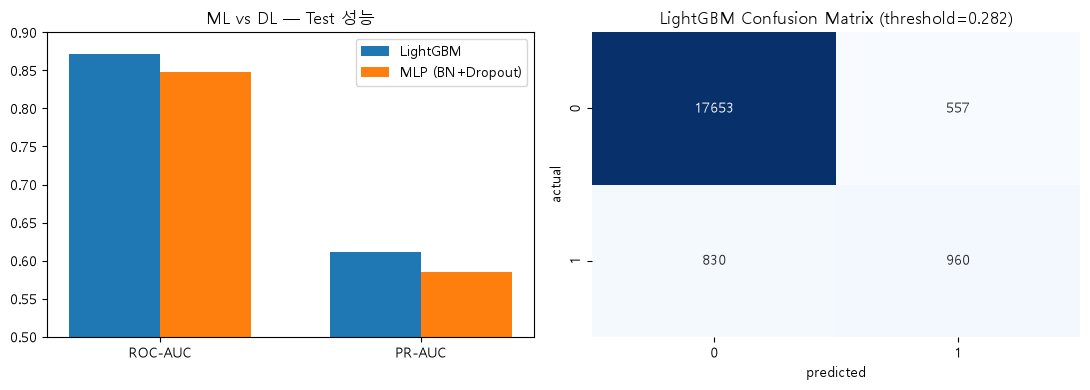

              precision    recall  f1-score   support

           0       0.96      0.97      0.96     18210
           1       0.63      0.54      0.58      1790

    accuracy                           0.93     20000
   macro avg       0.79      0.75      0.77     20000
weighted avg       0.93      0.93      0.93     20000



In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
metrics = ["ROC-AUC", "PR-AUC"]
x = np.arange(len(metrics)); w = 0.35
axes[0].bar(x - w/2, [lgb_th[m] for m in metrics], w, label="LightGBM")
axes[0].bar(x + w/2, [mlp[m] for m in metrics], w, label="MLP (BN+Dropout)")
axes[0].set_xticks(x, metrics); axes[0].set_ylim(0.5, 0.9); axes[0].legend()
axes[0].set_title("ML vs DL — Test 성능")

sns.heatmap(confusion_matrix(y_test, (proba_te >= TH).astype(int)), annot=True, fmt="d",
            cmap="Blues", ax=axes[1], cbar=False)
axes[1].set_xlabel("predicted"); axes[1].set_ylabel("actual")
axes[1].set_title(f"LightGBM Confusion Matrix (threshold={TH:.3f})")
plt.tight_layout(); plt.show()

print(classification_report(y_test, (proba_te >= TH).astype(int)))

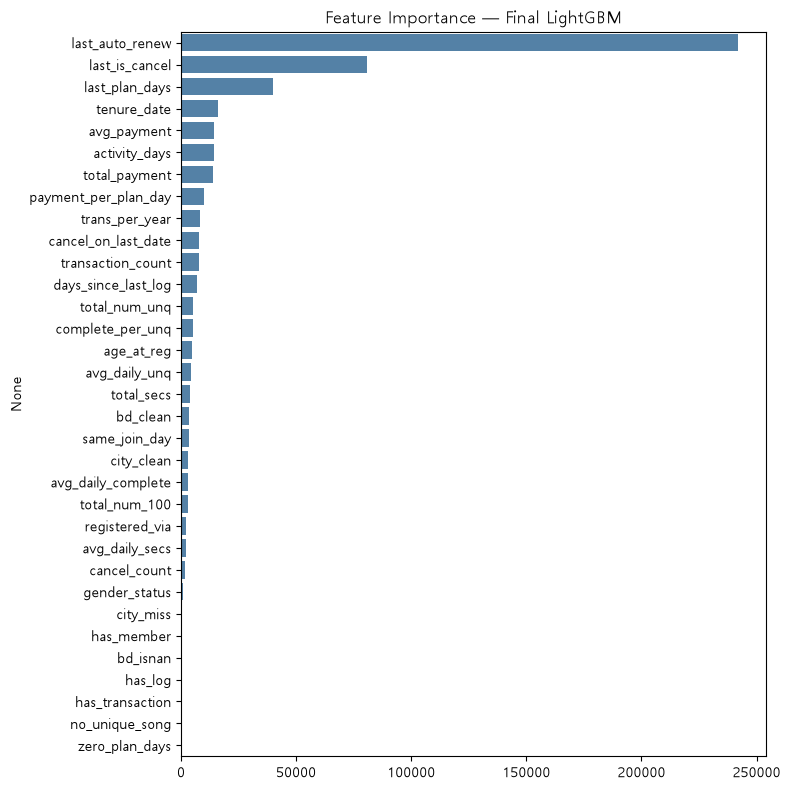

In [21]:
imp = pd.Series(final_model.feature_importances_, index=x_train.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 8))
sns.barplot(x=imp.values, y=imp.index, color="steelblue")
plt.title("Feature Importance — Final LightGBM")
plt.tight_layout(); plt.show()

**최종 결론**
- 최종 모델: **LightGBM (n_estimators=200, learning_rate≈0.020, num_leaves=53, min_child_samples=41)**
- 운영 기준선: **F1 최대 기준선(약 0.28)** — 기준선 0.5보다 재현율이 0.41 → 0.54로 오르고, 정밀도 0.63 유지
- DL 최고 모델(BN+Dropout MLP) 대비 ROC-AUC +0.023, PR-AUC +0.026
- 한계: lgb `learning_rate` 최적값이 탐색 범위 하한(0.02)에 붙어 있음 → 범위를 넓혀 재탐색할 여지 있음 (튜닝 효과 자체는 +0.0016으로 오차 범위 안)

# 6. Save Final Model
새 데이터에 같은 전처리를 적용하려면 모델뿐 아니라 **기준선·피처 순서·범주 레벨·학습 데이터 기준값**도 필요하므로 한 파일에 같이 저장합니다.

In [22]:
import joblib

MODEL_DIR = Path("../../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "final_model_lgb.pkl"

bundle = {
    "model": final_model,
    "model_name": "LightGBM (tuned)",
    "params": BEST_PARAMS,
    "threshold": TH,
    "features": all_col,
    "categories": categories,
    "category_levels": {c: x_train[c].cat.categories.tolist() for c in categories},
    "keep_cities": keep_cities.tolist(),   # city_clean 변환 기준
    "join_cnt": join_cnt,                  # same_join_day 계산 기준
    "today": TODAY,
    "test_score": final_cmp[f"LightGBM (기준선 {TH:.3f}) ★최종"].to_dict(),
}
joblib.dump(bundle, MODEL_PATH)
print("저장 완료:", MODEL_PATH.resolve())

저장 완료: C:\dev\project\SKN36-2nd-1Team\models\final_model_lgb.pkl


## Load Check
저장한 파일을 다시 불러와 같은 점수가 나오는지 확인합니다.

In [23]:
loaded = joblib.load(MODEL_PATH)

x_chk = x_test[loaded["features"]].copy()
for c in loaded["categories"]:
    x_chk[c] = pd.Categorical(x_chk[c].astype(object), categories=loaded["category_levels"][c])

proba_chk = loaded["model"].predict_proba(x_chk)[:, 1]
pred_chk = (proba_chk >= loaded["threshold"]).astype(int)

print(f"ROC-AUC {roc_auc_score(y_test, proba_chk):.4f} | 재현율 {recall_score(y_test, pred_chk):.4f} "
      f"| 정밀도 {precision_score(y_test, pred_chk):.4f}")
assert np.allclose(proba_chk, proba_te), "저장 전후 예측이 다릅니다"
print("✅ 저장 전후 예측 일치")

ROC-AUC 0.8719 | 재현율 0.5363 | 정밀도 0.6328
✅ 저장 전후 예측 일치


# 7. SHAP 분석 — 전체 모델 → 고객 유형 → 대표 고객

기존 최종 LightGBM 모델은 그대로 두고, 여기부터 SHAP 분석만 추가합니다.

분석 흐름:
1. Test 20,000명 전체 SHAP → 모델의 전반적인 판단 기준 확인
2. 기존 고객 유형화와 동일한 방식으로 위험 고객을 4개 Cluster로 재현
3. 유형별 평균 SHAP → 유형에서 공통적으로 중요한 이탈 위험 요인 확인
4. 각 유형의 평균 SHAP 패턴과 가장 가까운 대표 고객 1명 선정
5. 대표 고객 4명의 개별 SHAP → 실제 고객 단위의 이탈 위험 요인 확인

> SHAP은 모델의 예측 근거를 설명하며, 인과관계를 증명하지는 않습니다.

## 7-1. Test 데이터 기준 전체 SHAP

학습에 사용하지 않은 Test 20,000명을 기준으로 최종 LightGBM의 전체 SHAP을 확인합니다.

- 평균 `|SHAP|`가 클수록 모델 예측에 전반적으로 영향이 큰 변수
- SHAP `+`는 이탈 예측을 높이는 방향
- SHAP `-`는 이탈 예측을 낮추는 방향

In [24]:
import shap

explainer = shap.TreeExplainer(final_model)

def get_binary_shap(raw):
    if isinstance(raw, list):
        return np.asarray(raw[-1])

    arr = np.asarray(raw)

    if arr.ndim == 3:
        if arr.shape[-1] == 2:
            return arr[:, :, 1]
        if arr.shape[0] == 2:
            return arr[1]

    return arr

def get_binary_base_value(explainer):
    base = np.asarray(explainer.expected_value)
    if base.ndim == 0:
        return float(base)
    return float(base.reshape(-1)[-1])

sv_test = get_binary_shap(explainer.shap_values(x_test))

print("x_test shape:", x_test.shape)
print("SHAP shape:", sv_test.shape)
assert sv_test.shape == x_test.shape

c:\dev\project\SKN36-2nd-1Team\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


x_test shape: (20000, 33)
SHAP shape: (20000, 33)


c:\dev\project\SKN36-2nd-1Team\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


,mean_abs_shap
last_auto_renew,0.5763
payment_per_plan_day,0.1923
tenure_date,0.1474
avg_payment,0.1426
total_payment,0.0762
last_is_cancel,0.0733
last_plan_days,0.0654
days_since_last_log,0.0618
trans_per_year,0.0487
activity_days,0.0476


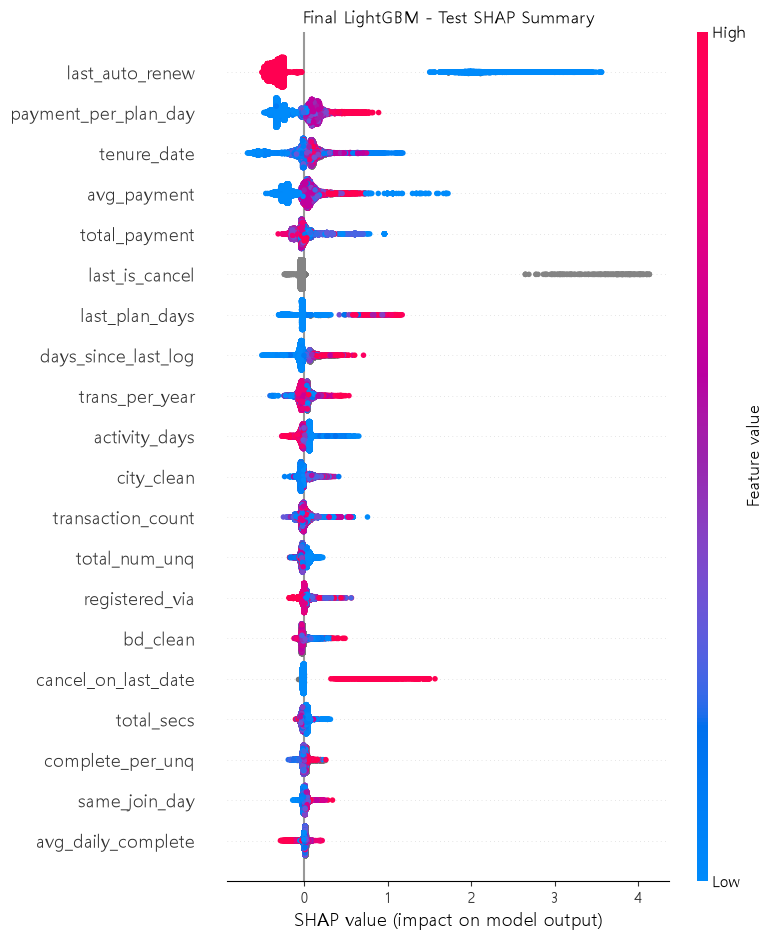

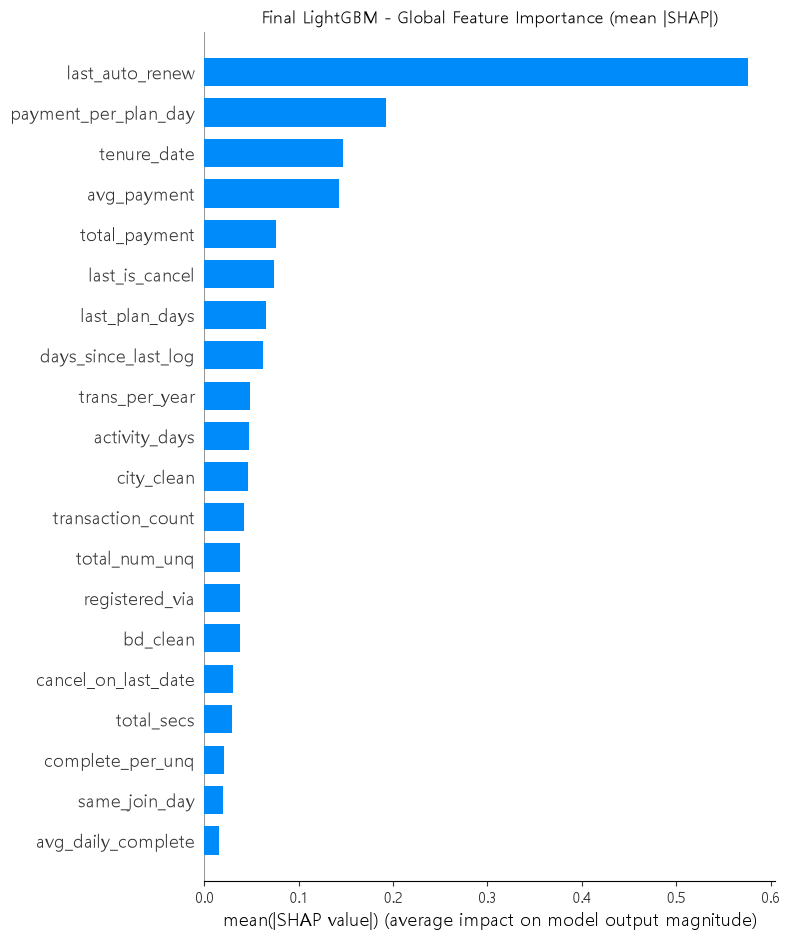

In [25]:
global_shap = (
    pd.Series(
        np.abs(sv_test).mean(axis=0),
        index=x_test.columns,
        name="mean_abs_shap"
    )
    .sort_values(ascending=False)
)

display(global_shap.head(15).to_frame().round(4))

x_test_plot = x_test.copy()
for c in categories:
    x_test_plot[c] = x_test_plot[c].cat.codes.astype(float)

x_test_plot = x_test_plot.astype(float)

shap.summary_plot(sv_test, x_test_plot, max_display=20, show=False)
plt.title("Final LightGBM - Test SHAP Summary")
plt.tight_layout()
plt.show()

shap.summary_plot(
    sv_test,
    x_test_plot,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("Final LightGBM - Global Feature Importance (mean |SHAP|)")
plt.tight_layout()
plt.show()

## 7-2. 전체 SHAP 결과 해석

Test 데이터 20,000명을 기준으로 평균 `|SHAP|`를 확인한 결과, 모델은 다음 변수를 중요하게 활용하였다.

1. `last_auto_renew` : **0.5763**
2. `payment_per_plan_day` : **0.1923**
3. `tenure_date` : **0.1474**
4. `avg_payment` : **0.1426**
5. `total_payment` : **0.0762**

→ 최종 LightGBM은 전체적으로 **자동갱신 여부, 결제 특성, 고객 관계 기간**을 중요하게 보고 이탈을 예측하였다.

특히 `last_auto_renew`의 평균 `|SHAP|`가 다른 변수보다 크게 나타나,  
전체 모델에서 가장 영향력이 큰 변수임을 확인할 수 있다.

# 8. 고객 유형화 결과 재현

고객 유형화 노트북과 같은 기준을 사용합니다.

- 최종 모델 기준선 `TH` 이상 → 이탈 위험 고객
- 위험 고객 중 클러스터링 Feature에 결측이 없는 고객만 사용
- 동일한 로그 변환 / Scaling / K-Means(`k=4`) 적용
- SHAP의 유형별 분석은 실제 Cluster가 부여된 고객을 대상으로 수행

고객 유형화 노트북의 실행 결과:
- 위험 고객: **7,515명**
- 결측 제거 후 군집화 고객: **6,696명**
- Cluster 수: **4개**

In [26]:
x_all = df_all[all_col].copy()

for c in categories:
    x_all[c] = x_all[c].astype("category")

proba_all = final_model.predict_proba(x_all)[:, 1]

customer_all = df_all[["msno", "is_churn"]].copy()
customer_all["churn_prob"] = proba_all

risk_mask = customer_all["churn_prob"] >= TH
risk_customers = customer_all.loc[risk_mask].copy()
risk_df = df_all.loc[risk_customers.index].copy()

print(f"Threshold: {TH:.4f}")
print(f"전체 고객 수: {len(customer_all):,}")
print(f"이탈 위험 고객 수: {len(risk_customers):,}")

Threshold: 0.2824
전체 고객 수: 100,000
이탈 위험 고객 수: 7,515


In [27]:
cluster_features = [
    "transaction_count",
    "cancel_count",
    "last_auto_renew",
    "last_is_cancel",
    "last_plan_days",
    "days_to_expire",
    "trans_per_year",
    "cancel_per_year",
    "avg_payment",
    "payment_per_plan_day",
    "pay_per_year",
    "activity_days",
    "days_since_last_log",
    "no_unique_song",
    "avg_daily_secs",
    "avg_daily_unq",
    "complete_per_unq",
    "tenure_date",
]

X_cluster = risk_df[cluster_features].copy()
X_cluster_complete = X_cluster.dropna().copy()

print("기존 위험 고객 수:", len(X_cluster))
print("결측 제거 후 고객 수:", len(X_cluster_complete))
print("제거된 고객 수:", len(X_cluster) - len(X_cluster_complete))

기존 위험 고객 수: 7515
결측 제거 후 고객 수: 6696
제거된 고객 수: 819


In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

skewness = X_cluster_complete.skew().sort_values(ascending=False)
log_candidates = skewness[skewness > 1].index.tolist()

binary_features = [
    "last_auto_renew",
    "last_is_cancel",
    "no_unique_song",
]

log_features = [
    col for col in log_candidates
    if col not in binary_features
    and X_cluster_complete[col].min() >= 0
]

X_cluster_transformed = X_cluster_complete.copy()

for col in log_features:
    X_cluster_transformed[col] = np.log1p(X_cluster_transformed[col])

restore_features = [
    "complete_per_unq",
    "pay_per_year",
    "tenure_date",
]

for col in restore_features:
    X_cluster_transformed[col] = X_cluster_complete[col]

scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X_cluster_transformed),
    columns=X_cluster_transformed.columns,
    index=X_cluster_transformed.index,
)

X_scaled = X_scaled.drop(columns=["no_unique_song"])

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10,
)

cluster_labels = kmeans.fit_predict(X_scaled)

cluster_meta = pd.DataFrame(
    {"cluster": cluster_labels},
    index=X_scaled.index,
)

cluster_names = {
    0: "저활동·단기 구독형",
    1: "반복 거래·취소 위험형",
    2: "장기 플랜·고결제 고위험형",
    3: "장기 관계·고빈도 거래형",
}

cluster_meta["cluster_name"] = cluster_meta["cluster"].map(cluster_names)
cluster_meta["msno"] = df_all.loc[cluster_meta.index, "msno"]
cluster_meta["is_churn"] = df_all.loc[cluster_meta.index, "is_churn"]
cluster_meta["churn_prob"] = proba_all[cluster_meta.index]

cluster_overview = (
    cluster_meta
    .groupby(["cluster", "cluster_name"])
    .agg(
        customer_count=("msno", "count"),
        avg_churn_prob=("churn_prob", "mean"),
        actual_churn_rate=("is_churn", "mean"),
    )
)

display(cluster_overview.round(4))

,,customer_count,avg_churn_prob,actual_churn_rate
cluster,cluster_name,,,
0,저활동·단기 구독형,3437,0.4518,0.5161
1,반복 거래·취소 위험형,681,0.7373,0.7577
2,장기 플랜·고결제 고위험형,1748,0.8443,0.8627
3,장기 관계·고빈도 거래형,830,0.5696,0.6373


## 8-1. 고객 유형화 결과 확인

최종 모델의 기준선 `TH = 0.2824` 이상인 고객은 **7,515명**이었고,  
클러스터링 Feature의 결측치를 제거한 뒤 실제 유형화에 사용된 고객은 **6,696명**이었다.

고객 유형화 결과는 다음과 같다.

| Cluster | 고객 유형 | 고객 수 | 평균 이탈확률 | 실제 이탈률 |
|---|---|---:|---:|---:|
| 0 | 저활동·단기 구독형 | 3,437명 | 45.18% | 51.61% |
| 1 | 반복 거래·취소 위험형 | 681명 | 73.73% | 75.77% |
| 2 | 장기 플랜·고결제 고위험형 | 1,748명 | 84.43% | 86.27% |
| 3 | 장기 관계·고빈도 거래형 | 830명 | 56.96% | 63.73% |

→ 기존 고객 유형화 노트북의 4개 Cluster 결과와 동일하게 재현되었다.  
이후 SHAP 분석은 이 6,696명의 유형 정보를 그대로 사용한다.

# 9. 유형별 평균 SHAP

Cluster가 부여된 고객들을 대상으로 최종 LightGBM의 SHAP을 계산합니다.

유형별로 두 값을 함께 봅니다.

- **평균 |SHAP|** → 그 유형에서 어떤 변수가 중요하게 작용했는지
- **평균 SHAP** → 그 변수가 평균적으로 이탈 위험을 높이는지(`+`) 낮추는지(`-`)

따라서 중요도와 방향을 같이 확인합니다.

> 유형별 SHAP 분석은 고객 유형화와 동일하게 전체 위험 고객군을 대상으로 하므로,       
> 일부 고객은 모델 학습에 사용된 Train 데이터에 포함되어 있다.        
> 모델 자체의 일반적인 해석은 7번의 Test SHAP을 기준으로 보고,         
> 9번 이후 결과는 실제 위험 고객의 유형별 특성을 설명하기 위한 분석으로 활용한다.     

In [29]:
cluster_index = X_scaled.index
x_cluster_model = x_all.loc[cluster_index].copy()

sv_cluster = get_binary_shap(
    explainer.shap_values(x_cluster_model)
)

assert sv_cluster.shape == x_cluster_model.shape

shap_cluster_df = pd.DataFrame(
    sv_cluster,
    index=cluster_index,
    columns=all_col,
)

print("군집 SHAP 대상 고객 수:", len(shap_cluster_df))

display(
    cluster_meta
    .groupby(["cluster", "cluster_name"])
    .size()
    .to_frame("고객수")
)

군집 SHAP 대상 고객 수: 6696


c:\dev\project\SKN36-2nd-1Team\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


,,고객수
cluster,cluster_name,
0,저활동·단기 구독형,3437
1,반복 거래·취소 위험형,681
2,장기 플랜·고결제 고위험형,1748
3,장기 관계·고빈도 거래형,830


In [30]:
cluster_shap_rows = []

for cluster_id in sorted(cluster_meta["cluster"].unique()):
    idx = cluster_meta.index[cluster_meta["cluster"] == cluster_id]
    values = shap_cluster_df.loc[idx]

    mean_abs = values.abs().mean()
    mean_signed = values.mean()

    tmp = pd.DataFrame({
        "cluster": cluster_id,
        "cluster_name": cluster_names[cluster_id],
        "feature": all_col,
        "mean_abs_shap": mean_abs.values,
        "mean_shap": mean_signed.values,
    })

    tmp["direction"] = np.where(
        tmp["mean_shap"] > 0,
        "이탈 위험↑",
        np.where(tmp["mean_shap"] < 0, "이탈 위험↓", "중립")
    )

    cluster_shap_rows.append(tmp)

cluster_shap_summary = pd.concat(
    cluster_shap_rows,
    ignore_index=True
)

for cluster_id in sorted(cluster_names):
    print(f"\n===== Cluster {cluster_id} — {cluster_names[cluster_id]} =====")

    imp_top = (
        cluster_shap_summary[
            cluster_shap_summary["cluster"] == cluster_id
        ]
        .sort_values("mean_abs_shap", ascending=False)
        .head(10)
    )

    display(
        imp_top[
            ["feature", "mean_abs_shap", "mean_shap", "direction"]
        ].round(4)
    )


===== Cluster 0 — 저활동·단기 구독형 =====


,feature,mean_abs_shap,mean_shap,direction
13,last_auto_renew,2.3394,2.3358,이탈 위험↑
15,last_plan_days,0.2134,-0.1316,이탈 위험↓
18,activity_days,0.1803,0.1513,이탈 위험↑
30,payment_per_plan_day,0.1577,0.1512,이탈 위험↑
25,avg_payment,0.1094,0.1048,이탈 위험↑
22,days_since_last_log,0.0884,0.0153,이탈 위험↑
21,total_num_unq,0.0671,0.0331,이탈 위험↑
24,trans_per_year,0.0646,0.0145,이탈 위험↑
10,transaction_count,0.0587,0.0498,이탈 위험↑
12,total_payment,0.0545,0.0393,이탈 위험↑



===== Cluster 1 — 반복 거래·취소 위험형 =====


,feature,mean_abs_shap,mean_shap,direction
47,last_is_cancel,3.3439,3.3402,이탈 위험↑
49,cancel_on_last_date,0.8697,0.8686,이탈 위험↑
55,days_since_last_log,0.3014,-0.0352,이탈 위험↓
58,avg_payment,0.1241,0.1204,이탈 위험↑
54,total_num_unq,0.0993,-0.0421,이탈 위험↓
46,last_auto_renew,0.0968,-0.0686,이탈 위험↓
63,payment_per_plan_day,0.0875,0.0797,이탈 위험↑
62,complete_per_unq,0.0731,-0.0638,이탈 위험↓
37,tenure_date,0.0691,0.0338,이탈 위험↑
51,activity_days,0.0651,-0.0160,이탈 위험↓



===== Cluster 2 — 장기 플랜·고결제 고위험형 =====


,feature,mean_abs_shap,mean_shap,direction
79,last_auto_renew,3.1432,3.1432,이탈 위험↑
81,last_plan_days,1.0034,1.0010,이탈 위험↑
91,avg_payment,0.4401,0.4394,이탈 위험↑
96,payment_per_plan_day,0.0765,0.0586,이탈 위험↑
90,trans_per_year,0.0669,0.0586,이탈 위험↑
84,activity_days,0.0558,-0.0339,이탈 위험↓
88,days_since_last_log,0.0499,-0.0122,이탈 위험↓
70,tenure_date,0.0440,0.0325,이탈 위험↑
76,transaction_count,0.0414,0.0396,이탈 위험↑
67,city_clean,0.0340,0.0265,이탈 위험↑



===== Cluster 3 — 장기 관계·고빈도 거래형 =====


,feature,mean_abs_shap,mean_shap,direction
112,last_auto_renew,2.5489,2.5261,이탈 위험↑
114,last_plan_days,0.5539,0.3906,이탈 위험↑
124,avg_payment,0.2474,0.2087,이탈 위험↑
123,trans_per_year,0.1210,-0.0299,이탈 위험↓
117,activity_days,0.0998,0.0152,이탈 위험↑
129,payment_per_plan_day,0.0968,0.0889,이탈 위험↑
111,total_payment,0.0793,0.0317,이탈 위험↑
103,tenure_date,0.0642,0.0313,이탈 위험↑
109,transaction_count,0.0503,0.0262,이탈 위험↑
121,days_since_last_log,0.0498,-0.0103,이탈 위험↓


In [31]:
cluster_risk_top5 = (
    cluster_shap_summary[
        cluster_shap_summary["mean_shap"] > 0
    ]
    .sort_values(
        ["cluster", "mean_shap"],
        ascending=[True, False]
    )
    .groupby("cluster", group_keys=False)
    .head(5)
)

display(
    cluster_risk_top5[
        [
            "cluster",
            "cluster_name",
            "feature",
            "mean_abs_shap",
            "mean_shap",
        ]
    ].round(4)
)

,cluster,cluster_name,feature,mean_abs_shap,mean_shap
13,0,저활동·단기 구독형,last_auto_renew,2.3394,2.3358
18,0,저활동·단기 구독형,activity_days,0.1803,0.1513
30,0,저활동·단기 구독형,payment_per_plan_day,0.1577,0.1512
25,0,저활동·단기 구독형,avg_payment,0.1094,0.1048
0,0,저활동·단기 구독형,registered_via,0.0530,0.0526
47,1,반복 거래·취소 위험형,last_is_cancel,3.3439,3.3402
49,1,반복 거래·취소 위험형,cancel_on_last_date,0.8697,0.8686
58,1,반복 거래·취소 위험형,avg_payment,0.1241,0.1204
63,1,반복 거래·취소 위험형,payment_per_plan_day,0.0875,0.0797
45,1,반복 거래·취소 위험형,total_payment,0.0603,0.0409


## 9-1. 유형별 평균 |SHAP| 그래프

아래 4개의 막대그래프가 **유형별 평균 SHAP 중요도 그래프**이다.

각 그래프는 Cluster 0~3을 각각 보여주며,  
막대 길이는 해당 유형에서 변수의 평균 `|SHAP|`를 의미한다.

> 평균 `|SHAP|`는 **영향의 크기**를 보여주고,  
> 이탈 위험을 높이는지 낮추는지는 위 표의 `mean_shap`과 `direction`을 함께 확인해야 한다.

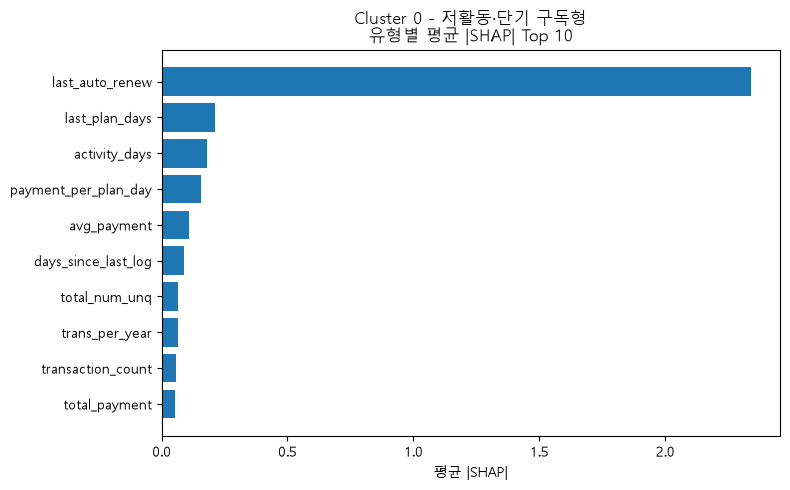

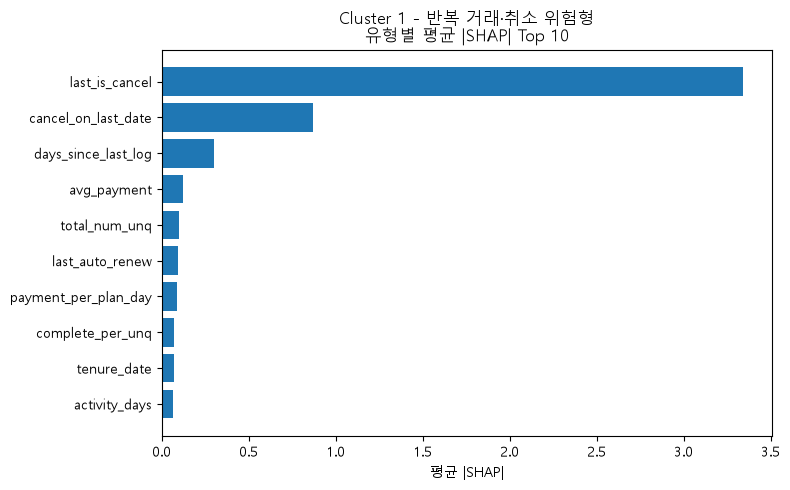

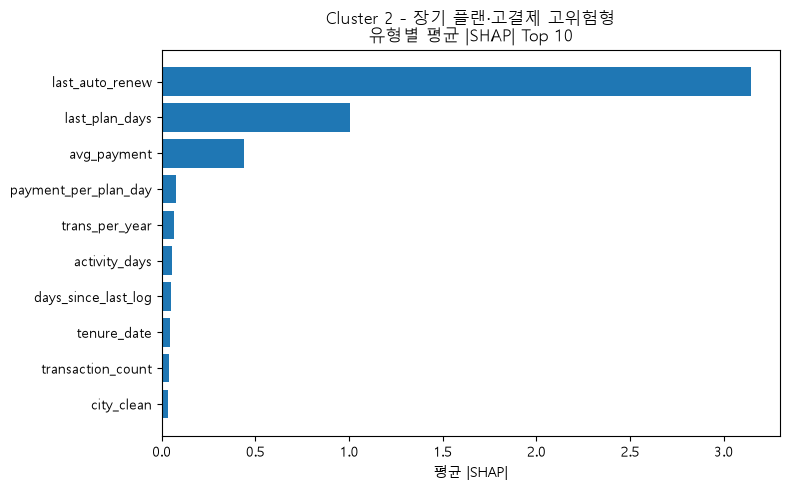

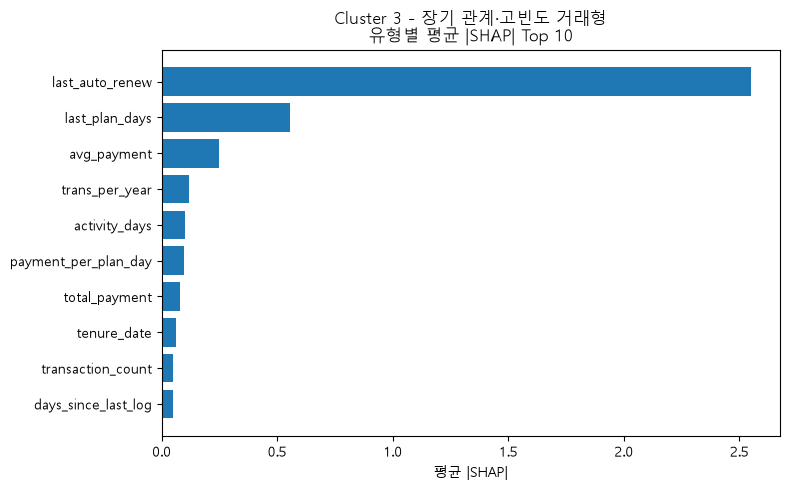

In [32]:
for cluster_id in sorted(cluster_names):
    plot_df = (
        cluster_shap_summary[
            cluster_shap_summary["cluster"] == cluster_id
        ]
        .nlargest(10, "mean_abs_shap")
        .sort_values("mean_abs_shap")
    )

    plt.figure(figsize=(8, 5))
    plt.barh(plot_df["feature"], plot_df["mean_abs_shap"])
    plt.xlabel("평균 |SHAP|")
    plt.title(
        f"Cluster {cluster_id} - {cluster_names[cluster_id]}\n"
        "유형별 평균 |SHAP| Top 10"
    )
    plt.tight_layout()
    plt.show()

## 9-2. 유형별 SHAP 결과 해석

### Cluster 0 — 저활동·단기 구독형

주요 이탈 위험 증가 요인은 다음과 같다.

- `last_auto_renew` : 평균 SHAP **+2.3358**
- `activity_days` : **+0.1513**
- `payment_per_plan_day` : **+0.1512**
- `avg_payment` : **+0.1048**

반면 `last_plan_days`는 평균 SHAP **-0.1316**으로 이탈 위험을 낮추는 방향으로 나타났다.

→ 이 유형에서는 특히 **자동갱신 관련 상태가 가장 큰 영향을 보였고, 활동량과 결제 특성도 함께 영향을 주었다.**

---

### Cluster 1 — 반복 거래·취소 위험형

주요 이탈 위험 증가 요인은 다음과 같다.

- `last_is_cancel` : 평균 SHAP **+3.3402**
- `cancel_on_last_date` : **+0.8686**
- `avg_payment` : **+0.1204**
- `payment_per_plan_day` : **+0.0797**

→ 다른 유형과 달리 **실제 취소 행동 관련 변수의 영향이 매우 크게 나타났다.**  
특히 마지막 거래에서 취소가 발생했는지가 이탈 위험 예측을 크게 높였다.

---

### Cluster 2 — 장기 플랜·고결제 고위험형

주요 이탈 위험 증가 요인은 다음과 같다.

- `last_auto_renew` : 평균 SHAP **+3.1432**
- `last_plan_days` : **+1.0010**
- `avg_payment` : **+0.4394**
- `payment_per_plan_day` : **+0.0586**
- `trans_per_year` : **+0.0586**

→ **자동갱신 여부, 긴 플랜 기간, 높은 결제금액**이 이 유형의 높은 이탈 위험 예측에 크게 기여하였다.

---

### Cluster 3 — 장기 관계·고빈도 거래형

주요 이탈 위험 증가 요인은 다음과 같다.

- `last_auto_renew` : 평균 SHAP **+2.5261**
- `last_plan_days` : **+0.3906**
- `avg_payment` : **+0.2087**
- `payment_per_plan_day` : **+0.0889**

반면 `trans_per_year`는 평균 SHAP **-0.0299**로 이탈 위험을 낮추는 방향으로 나타났다.

→ 장기 고객이라고 하더라도 모든 행동 특성이 이탈 위험을 높이는 것은 아니며,  
이 유형에서는 **자동갱신, 플랜 기간, 결제 특성**이 주요 위험 요인으로 나타났다.

---

### 유형별 비교

- Cluster 0 : 자동갱신 + 활동량 + 결제 특성
- Cluster 1 : 최근 취소 여부와 취소 행동
- Cluster 2 : 자동갱신 + 장기 플랜 + 높은 결제금액
- Cluster 3 : 자동갱신 + 플랜 기간 + 결제 특성

→ 전체 모델에서는 `last_auto_renew`가 가장 중요했지만,  
유형별로 세분화하면 **각 유형마다 중요하게 작용하는 위험 요인이 달라짐**을 확인할 수 있다.

# 10. 각 유형의 대표 고객 1명 선정

대표 고객은 임의로 고르지 않고, **각 유형의 평균 signed SHAP 벡터와 가장 가까운 실제 고객**을 선택합니다.

- 유형 평균 SHAP = 해당 유형 전체의 평균적인 모델 판단 패턴
- 대표 고객 SHAP = 그 평균 패턴과 가장 가까운 실제 한 고객

두 값이 완전히 같은 것은 아니며, 유형 내 고객 중 가장 유사한 고객입니다.

33개 최종 모델 Feature의 SHAP 값에 대해 유클리드 거리를 계산합니다.

In [33]:
representative_rows = []

for cluster_id in sorted(cluster_names):
    idx = cluster_meta.index[
        cluster_meta["cluster"] == cluster_id
    ]

    cluster_values = shap_cluster_df.loc[idx]
    mean_pattern = cluster_values.mean(axis=0)

    distances = np.sqrt(
        ((cluster_values - mean_pattern) ** 2).sum(axis=1)
    )

    rep_idx = distances.idxmin()

    representative_rows.append({
        "cluster": cluster_id,
        "cluster_name": cluster_names[cluster_id],
        "row_index": rep_idx,
        "msno": df_all.loc[rep_idx, "msno"],
        "churn_prob": proba_all[rep_idx],
        "is_churn": df_all.loc[rep_idx, "is_churn"],
        "shap_distance_to_cluster_mean": distances.loc[rep_idx],
    })

representatives = pd.DataFrame(representative_rows)

display(
    representatives[
        [
            "cluster",
            "cluster_name",
            "churn_prob",
            "is_churn",
            "shap_distance_to_cluster_mean",
        ]
    ].round(4)
)

,cluster,cluster_name,churn_prob,is_churn,shap_distance_to_cluster_mean
0,0,저활동·단기 구독형,0.4191,0,0.1621
1,1,반복 거래·취소 위험형,0.7058,1,0.1892
2,2,장기 플랜·고결제 고위험형,0.8531,1,0.0910
3,3,장기 관계·고빈도 거래형,0.5223,0,0.3265


## 10-1. 대표 고객 선정 결과 해석

각 유형에서 **유형 평균 signed SHAP 패턴과 가장 가까운 실제 고객**을 1명씩 선정하였다.

| Cluster | 대표 고객 이탈확률 | 실제 이탈 | 평균 SHAP과의 거리 |
|---|---:|---:|---:|
| 0 | 41.91% | 0 | 0.1621 |
| 1 | 70.58% | 1 | 0.1892 |
| 2 | 85.31% | 1 | 0.0910 |
| 3 | 52.23% | 0 | 0.3265 |

`shap_distance_to_cluster_mean`은 대표 고객의 SHAP 패턴과 유형 평균 SHAP 패턴 사이의 거리이다.  
값이 작을수록 유형 평균과 더 비슷한 고객이라는 의미이다.

대표 고객은 **처음부터 유형 평균에 가장 가까운 고객을 선택했기 때문에**,  
이후 개별 SHAP 결과가 유형 평균과 비슷하게 나타나는 것이 정상이다.

하지만 유형 평균은 여러 고객의 평균값이고, 대표 고객 SHAP은 실제 한 명의 값이므로  
두 값이 완전히 동일한 것은 아니다.

→ 대표 고객은 새로운 유형을 발견하기 위한 고객이 아니라,  
**해당 유형의 평균적인 특징을 실제 한 사람의 사례로 보여주기 위한 페르소나**이다.

# 11. 대표 고객 4명 개별 SHAP

각 유형의 대표 고객에 대해 다음을 확인합니다.

- 이탈 확률
- 실제 이탈 여부
- 이탈 위험을 높인 양수 SHAP 주요 요인
- 개별 Waterfall Plot

발표에서는  
**“이 유형 전체에서는 이런 요인이 중요했고, 대표 고객에게서는 이 요인들이 이렇게 작용했다.”**  
라는 흐름으로 설명할 수 있습니다.


Cluster 0 — 저활동·단기 구독형
대표 고객 row index: 5530
이탈확률: 0.419
실제 이탈 여부: 0


,feature,value,shap
0,last_auto_renew,0.0,2.2726
1,activity_days,14.0,0.2153
2,payment_per_plan_day,6.0,0.1579
3,transaction_count,4.0,0.0835
4,registered_via,4,0.0782


c:\dev\project\SKN36-2nd-1Team\.venv\Lib\site-packages\shap\plots\_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
c:\dev\project\SKN36-2nd-1Team\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


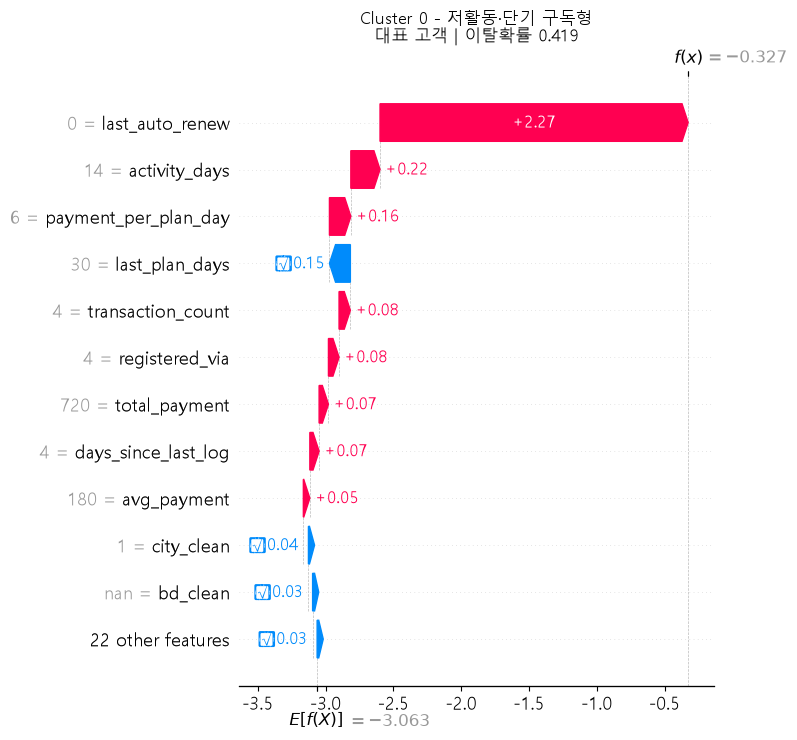


Cluster 1 — 반복 거래·취소 위험형
대표 고객 row index: 25029
이탈확률: 0.706
실제 이탈 여부: 1


,feature,value,shap
0,last_is_cancel,1.0,3.3729
1,cancel_on_last_date,1.0,0.8674
2,payment_per_plan_day,4.740909,0.0871
3,tenure_date,3447.0,0.0394
4,avg_daily_complete,44.714286,0.0358


c:\dev\project\SKN36-2nd-1Team\.venv\Lib\site-packages\shap\plots\_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
c:\dev\project\SKN36-2nd-1Team\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


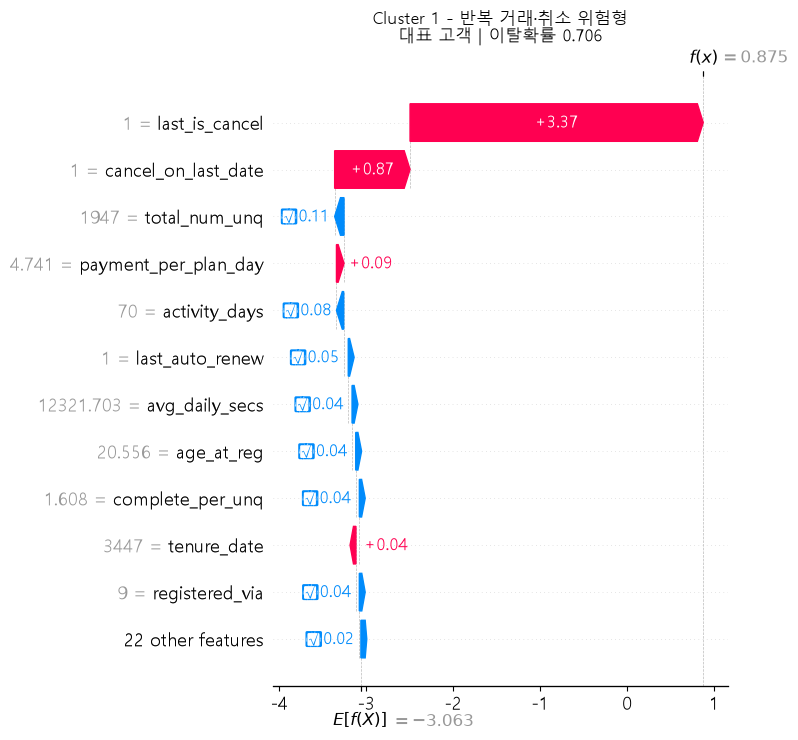


Cluster 2 — 장기 플랜·고결제 고위험형
대표 고객 row index: 75405
이탈확률: 0.853
실제 이탈 여부: 1


,feature,value,shap
0,last_auto_renew,0.0,3.1330
1,last_plan_days,410.0,1.0620
2,avg_payment,1788.0,0.4460
3,payment_per_plan_day,4.360976,0.0880
4,transaction_count,1.0,0.0622


c:\dev\project\SKN36-2nd-1Team\.venv\Lib\site-packages\shap\plots\_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
c:\dev\project\SKN36-2nd-1Team\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


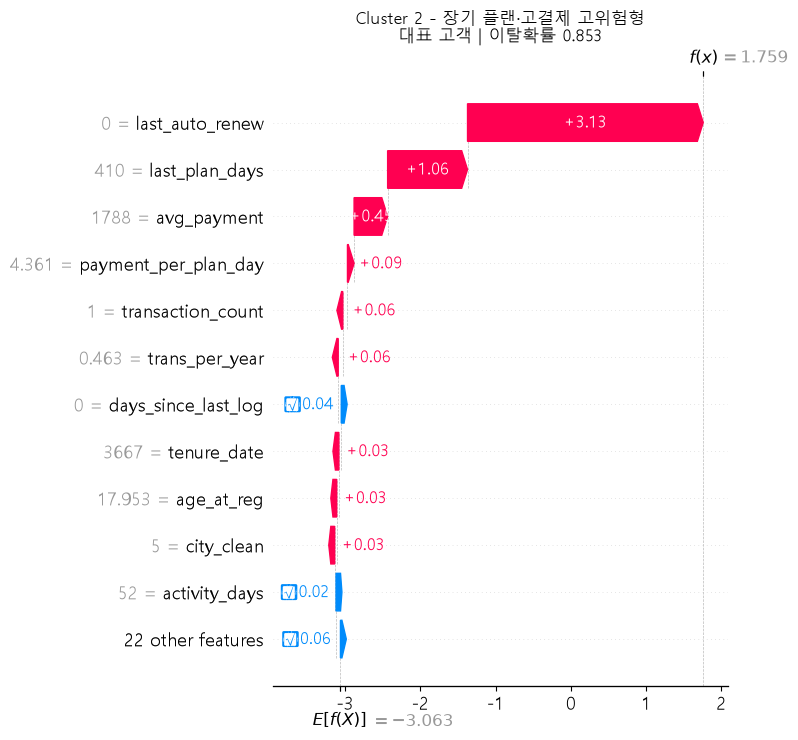


Cluster 3 — 장기 관계·고빈도 거래형
대표 고객 row index: 78358
이탈확률: 0.522
실제 이탈 여부: 0


,feature,value,shap
0,last_auto_renew,0.0,2.6649
1,last_plan_days,60.0,0.5781
2,avg_payment,225.0,0.2600
3,bd_clean,20.0,0.0357
4,age_at_reg,17.063014,0.0255


c:\dev\project\SKN36-2nd-1Team\.venv\Lib\site-packages\shap\plots\_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
c:\dev\project\SKN36-2nd-1Team\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


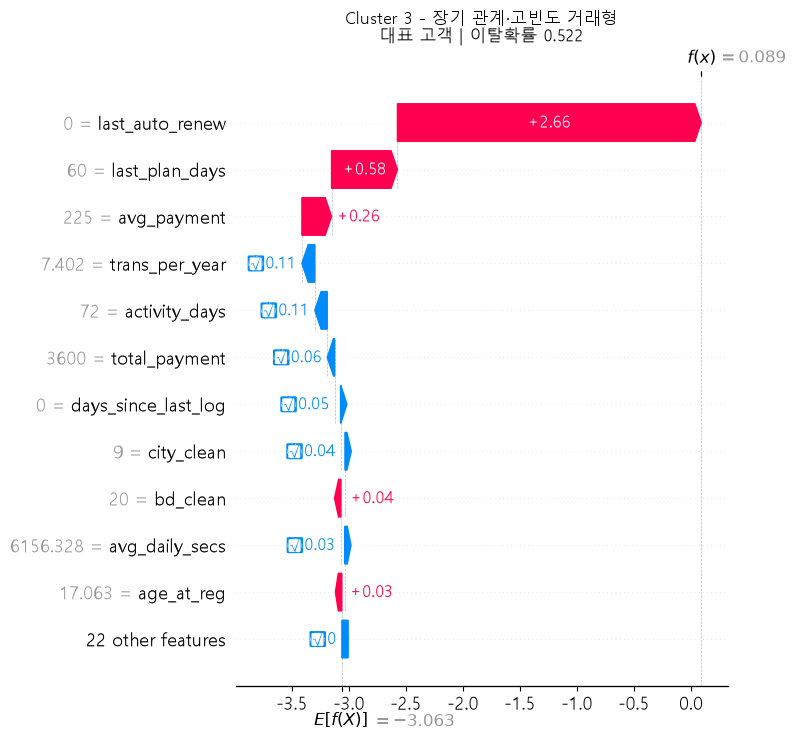

In [34]:
def positive_shap_top(df_row, shap_row, n=5):
    result = pd.DataFrame({
        "feature": all_col,
        "value": [df_row[c] for c in all_col],
        "shap": shap_row,
    })

    return (
        result[result["shap"] > 0]
        .sort_values("shap", ascending=False)
        .head(n)
        .reset_index(drop=True)
    )

representative_top_rows = []

for _, rep in representatives.iterrows():
    cluster_id = int(rep["cluster"])
    row_idx = int(rep["row_index"])

    shap_row = shap_cluster_df.loc[row_idx].values
    x_row = x_all.loc[row_idx]

    print("\n" + "=" * 80)
    print(f"Cluster {cluster_id} — {cluster_names[cluster_id]}")
    print(f"대표 고객 row index: {row_idx}")
    print(f"이탈확률: {proba_all[row_idx]:.3f}")
    print(f"실제 이탈 여부: {int(df_all.loc[row_idx, 'is_churn'])}")

    top = positive_shap_top(x_row, shap_row, n=5)
    display(top.round(4))

    for rank, row in top.iterrows():
        representative_top_rows.append({
            "cluster": cluster_id,
            "cluster_name": cluster_names[cluster_id],
            "row_index": row_idx,
            "msno": df_all.loc[row_idx, "msno"],
            "churn_prob": proba_all[row_idx],
            "is_churn": df_all.loc[row_idx, "is_churn"],
            "rank": rank + 1,
            "feature": row["feature"],
            "feature_value": row["value"],
            "shap": row["shap"],
        })

    explanation = shap.Explanation(
        values=shap_row,
        base_values=get_binary_base_value(explainer),
        data=x_row.values,
        feature_names=all_col,
    )

    shap.plots.waterfall(
        explanation,
        max_display=12,
        show=False
    )

    plt.title(
        f"Cluster {cluster_id} - {cluster_names[cluster_id]}\n"
        f"대표 고객 | 이탈확률 {proba_all[row_idx]:.3f}"
    )
    plt.tight_layout()
    plt.show()

representative_top_factors = pd.DataFrame(representative_top_rows)

## 11-1. 대표 고객별 개별 SHAP 해석

### Cluster 0 대표 고객 — 저활동·단기 구독형

- 이탈확률 : **41.9%**
- 실제 이탈 : **0**

주요 이탈 위험 증가 요인:

1. `last_auto_renew = 0` → SHAP **+2.2726**
2. `activity_days = 14` → **+0.2153**
3. `payment_per_plan_day = 6.0` → **+0.1579**
4. `transaction_count = 4` → **+0.0835**

→ 유형 평균에서 중요했던 `last_auto_renew`, `activity_days`, `payment_per_plan_day`가  
대표 고객에서도 비슷하게 나타났다.

---

### Cluster 1 대표 고객 — 반복 거래·취소 위험형

- 이탈확률 : **70.6%**
- 실제 이탈 : **1**

주요 이탈 위험 증가 요인:

1. `last_is_cancel = 1` → SHAP **+3.3729**
2. `cancel_on_last_date = 1` → **+0.8674**
3. `payment_per_plan_day ≈ 4.74` → **+0.0871**
4. `tenure_date = 3447` → **+0.0394**

→ 유형 평균과 마찬가지로 **최근 취소 행동 관련 변수가 압도적으로 큰 영향을 보였다.**

---

### Cluster 2 대표 고객 — 장기 플랜·고결제 고위험형

- 이탈확률 : **85.3%**
- 실제 이탈 : **1**

주요 이탈 위험 증가 요인:

1. `last_auto_renew = 0` → SHAP **+3.1330**
2. `last_plan_days = 410` → **+1.0620**
3. `avg_payment = 1788` → **+0.4460**
4. `payment_per_plan_day ≈ 4.36` → **+0.0880**
5. `transaction_count = 1` → **+0.0622**

→ 유형 전체에서 중요했던 **자동갱신, 장기 플랜, 높은 결제금액**이 대표 고객에서도 동일한 핵심 패턴으로 확인되었다.

---

### Cluster 3 대표 고객 — 장기 관계·고빈도 거래형

- 이탈확률 : **52.2%**
- 실제 이탈 : **0**

주요 이탈 위험 증가 요인:

1. `last_auto_renew = 0` → SHAP **+2.6649**
2. `last_plan_days = 60` → **+0.5781**
3. `avg_payment = 225` → **+0.2600**

→ 이 고객에서도 유형 전체와 마찬가지로 **자동갱신, 플랜 기간, 결제 특성**이 주요 위험 요인으로 나타났다.

> 대표 고객의 결과가 유형 평균과 비슷한 이유는 대표 고객을  
> 유형 평균 SHAP 패턴에 가장 가까운 고객으로 선정했기 때문이다.

# 12. 대표 고객 선정 결과 검증

이 부분은 새로운 분석을 하는 단계라기보다,  
**10번에서 선정한 대표 고객이 실제로 해당 유형의 평균 SHAP 패턴을 잘 대표하는지 확인하는 검증 단계**이다.

각 유형에서 평균 `|SHAP|`가 큰 Feature를 기준으로 다음 값을 비교한다.

- `cluster_mean_abs_shap` : 해당 유형에서 그 변수가 얼마나 중요했는지
- `cluster_mean_shap` : 해당 유형 전체에서 평균적으로 어느 방향으로 작용했는지
- `representative_shap` : 대표 고객 한 명에게서는 그 변수가 어떻게 작용했는지
- `representative_value` : 대표 고객이 실제로 가진 Feature 값

대표 고객은 유형 평균 SHAP과 가장 가까운 고객으로 선정했기 때문에  
주요 변수의 방향과 크기가 **비슷하게 나타나는 것이 자연스럽다.**

단, 유형 평균값과 대표 고객의 SHAP 값이 완전히 동일한 것은 아니다.

In [35]:
comparison_rows = []

for _, rep in representatives.iterrows():
    cluster_id = int(rep["cluster"])
    row_idx = int(rep["row_index"])

    idx = cluster_meta.index[
        cluster_meta["cluster"] == cluster_id
    ]

    mean_signed = shap_cluster_df.loc[idx].mean(axis=0)
    mean_abs = shap_cluster_df.loc[idx].abs().mean(axis=0)
    top_features = mean_abs.nlargest(8).index

    for feature in top_features:
        comparison_rows.append({
            "cluster": cluster_id,
            "cluster_name": cluster_names[cluster_id],
            "feature": feature,
            "cluster_mean_abs_shap": mean_abs[feature],
            "cluster_mean_shap": mean_signed[feature],
            "representative_shap": shap_cluster_df.loc[row_idx, feature],
            "representative_value": x_all.loc[row_idx, feature],
        })

cluster_rep_comparison = pd.DataFrame(comparison_rows)

for cluster_id in sorted(cluster_names):
    print(f"\nCluster {cluster_id} — {cluster_names[cluster_id]}")

    display(
        cluster_rep_comparison[
            cluster_rep_comparison["cluster"] == cluster_id
        ][
            [
                "feature",
                "cluster_mean_abs_shap",
                "cluster_mean_shap",
                "representative_shap",
                "representative_value",
            ]
        ].round(4)
    )


Cluster 0 — 저활동·단기 구독형


,feature,cluster_mean_abs_shap,cluster_mean_shap,representative_shap,representative_value
0,last_auto_renew,2.3394,2.3358,2.2726,0.000
1,last_plan_days,0.2134,-0.1316,-0.1544,30.000
2,activity_days,0.1803,0.1513,0.2153,14.000
3,payment_per_plan_day,0.1577,0.1512,0.1579,6.000
4,avg_payment,0.1094,0.1048,0.0479,180.000
5,days_since_last_log,0.0884,0.0153,0.0683,4.000
6,total_num_unq,0.0671,0.0331,0.0041,385.000
7,trans_per_year,0.0646,0.0145,-0.0028,9.359



Cluster 1 — 반복 거래·취소 위험형


,feature,cluster_mean_abs_shap,cluster_mean_shap,representative_shap,representative_value
8,last_is_cancel,3.3439,3.3402,3.3729,1.0000
9,cancel_on_last_date,0.8697,0.8686,0.8674,1.0000
10,days_since_last_log,0.3014,-0.0352,0.0179,5.0000
11,avg_payment,0.1241,0.1204,0.0179,142.2273
12,total_num_unq,0.0993,-0.0421,-0.1077,1947.0000
13,last_auto_renew,0.0968,-0.0686,-0.0524,1.0000
14,payment_per_plan_day,0.0875,0.0797,0.0871,4.7409
15,complete_per_unq,0.0731,-0.0638,-0.0416,1.6076



Cluster 2 — 장기 플랜·고결제 고위험형


,feature,cluster_mean_abs_shap,cluster_mean_shap,representative_shap,representative_value
16,last_auto_renew,3.1432,3.1432,3.1330,0.0000
17,last_plan_days,1.0034,1.0010,1.0620,410.0000
18,avg_payment,0.4401,0.4394,0.4460,1788.0000
19,payment_per_plan_day,0.0765,0.0586,0.0880,4.3610
20,trans_per_year,0.0669,0.0586,0.0610,0.4626
21,activity_days,0.0558,-0.0339,-0.0186,52.0000
22,days_since_last_log,0.0499,-0.0122,-0.0410,0.0000
23,tenure_date,0.0440,0.0325,0.0325,3667.0000



Cluster 3 — 장기 관계·고빈도 거래형


,feature,cluster_mean_abs_shap,cluster_mean_shap,representative_shap,representative_value
24,last_auto_renew,2.5489,2.5261,2.6649,0.0000
25,last_plan_days,0.5539,0.3906,0.5781,60.0000
26,avg_payment,0.2474,0.2087,0.2600,225.0000
27,trans_per_year,0.1210,-0.0299,-0.1131,7.4018
28,activity_days,0.0998,0.0152,-0.1093,72.0000
29,payment_per_plan_day,0.0968,0.0889,0.0122,3.7500
30,total_payment,0.0793,0.0317,-0.0645,3600.0000
31,tenure_date,0.0642,0.0313,-0.0189,1072.0000


## 12-1. 검증 결과 해석

12번 표는 **유형 평균과 대표 고객의 값이 같은지 보는 표가 아니라,  
대표 고객이 해당 유형의 평균적인 SHAP 패턴을 얼마나 잘 따라가는지 확인하는 표**이다.

예를 들어 Cluster 0의 `last_auto_renew`는:

- 유형 평균 SHAP : **+2.3358**
- 대표 고객 SHAP : **+2.2726**

으로 방향과 크기는 매우 비슷하지만 완전히 동일하지 않다.

`activity_days` 역시:

- 유형 평균 SHAP : **+0.1513**
- 대표 고객 SHAP : **+0.2153**

으로 차이가 존재한다.

Cluster 2의 `last_plan_days`도:

- 유형 평균 SHAP : **+1.0010**
- 대표 고객 SHAP : **+1.0620**

으로 비슷하지만 동일하지 않다.

→ 따라서 대표 고객은 유형 평균을 그대로 복사한 고객이 아니라,  
**실제 고객 중 유형 평균 패턴을 가장 잘 보여주는 고객**이라고 해석하면 된다.

이 표는 발표에서 반드시 보여줘야 하는 핵심 결과라기보다,  
대표 고객 선정 방식이 타당한지 확인하기 위한 **검증용 결과**로 보는 것이 적절하다.

# 13. 최종 종합 해석

최종 LightGBM의 Test SHAP에서는 `last_auto_renew`가 가장 중요한 변수로 나타났으며,  
결제 관련 변수와 고객 관계 기간도 모델 예측에 중요한 영향을 주었다.

이탈 위험 고객을 4개 유형으로 세분화한 뒤 유형별 SHAP을 확인한 결과,  
전체 모델에서 중요했던 변수가 모든 유형에서 동일하게 작용하는 것은 아니었다.

- **Cluster 0 — 저활동·단기 구독형**  
  자동갱신 여부와 활동량, 결제 특성이 주요 이탈 위험 요인으로 나타났다.
- **Cluster 1 — 반복 거래·취소 위험형**  
  `last_is_cancel`, `cancel_on_last_date` 등 실제 취소 행동 관련 변수가 가장 큰 영향을 보였다.
- **Cluster 2 — 장기 플랜·고결제 고위험형**  
  자동갱신 여부, 장기 플랜 기간, 높은 평균 결제금액이 주요 위험 요인으로 나타났다.
- **Cluster 3 — 장기 관계·고빈도 거래형**  
  자동갱신 여부, 플랜 기간, 결제 특성이 주요 위험 요인으로 나타났다.

각 유형에서는 유형 평균 SHAP 패턴과 가장 가까운 실제 고객 1명을 대표 고객으로 선정하였다.  
따라서 대표 고객의 SHAP 패턴이 유형 평균과 비슷하게 나타나는 것은 의도한 결과이며,  
대표 고객은 해당 유형의 특징을 실제 고객 사례로 보여주는 **페르소나 역할**을 한다.

최종적으로 이 분석은  
**전체 모델의 판단 기준 → 유형별 위험 요인 → 대표 고객의 개별 위험 요인**  
순서로 이탈 예측 결과를 설명할 수 있도록 구성하였다.

> SHAP은 실제 이탈의 인과 원인을 증명하는 값이 아니라,  
> 모델이 이탈 위험을 예측할 때 각 변수가 얼마나 영향을 주었는지를 설명하는 값이다.

In [36]:
DASHBOARD_DIR = Path("../../data/processed")
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)

feature_importance = (
    global_shap
    .rename_axis("feature")
    .reset_index(name="mean_abs_shap")
)

feature_importance["importance_rank"] = (
    feature_importance["mean_abs_shap"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

feature_importance.to_csv(
    DASHBOARD_DIR / "feature_importance.csv",
    index=False,
    encoding="utf-8-sig",
)

display(feature_importance.head(15))

,feature,mean_abs_shap,importance_rank
0,last_auto_renew,0.576339,1
1,payment_per_plan_day,0.192346,2
2,tenure_date,0.147356,3
3,avg_payment,0.142630,4
4,total_payment,0.076208,5
5,last_is_cancel,0.073288,6
6,last_plan_days,0.065429,7
7,days_since_last_log,0.061824,8
8,trans_per_year,0.048683,9
9,activity_days,0.047586,10


In [37]:
model_metrics = (
    final_cmp
    .T
    .reset_index()
    .rename(columns={"index": "model"})
)

model_metrics.to_csv(
    DASHBOARD_DIR / "model_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

display(model_metrics)

,model,ROC-AUC,PR-AUC,기준선,재현율,정밀도,F1
0,LightGBM (기준선 0.5),0.8719,0.6116,0.5000,0.4106,0.7895,0.5402
1,LightGBM (기준선 0.282) ★최종,0.8719,0.6116,0.2824,0.5363,0.6328,0.5806
2,MLP BN+Dropout (DL 1위),0.8485,0.5855,0.7548,0.5536,0.5742,0.5637
